In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, END, START

In [3]:
class AgentState(TypedDict):
    number1 : int
    number2 : int
    operation : str
    result : int

In [4]:
def adder_node(state: AgentState) -> AgentState:
    state["result"] = state["number1"] + state["number2"]
    return state

def subtracter_node(state: AgentState) -> AgentState:
    state["result"] = state["number1"] - state["number2"]
    return state

def router_node(state: AgentState) -> AgentState:
    if(state["operation"] == "+"):
        return "adder_node_usage"
    elif(state["operation"] == "-"):
        return "subtracter_node_usage"

In [5]:
graph = StateGraph(AgentState)
graph.add_node("adder", adder_node)
graph.add_node("subtracter", subtracter_node)
graph.add_node("router", lambda state:state)
graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    router_node,
    {
        "adder_node_usage": "adder",
        "subtracter_node_usage": "subtracter",
    }
)
graph.add_edge("adder",END)
graph.add_edge("subtracter",END)
app = graph.compile()

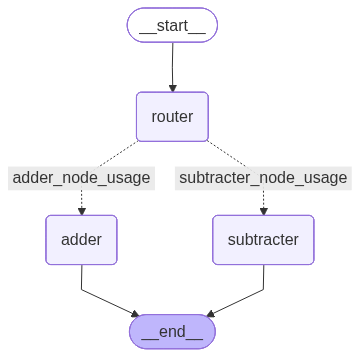

In [6]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))